In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pyvisa as visa
import time

kHz = 1e3
MHz = 1e6
GHz = 1e9

In [32]:
def setupXaxis(f_center, f_span, n_points, active_channel=1):
    
    kna.write(f":SENS{active_channel}:FREQ:CENT {f_center}")
    time.sleep(0.2)
    kna.write(f":SENS{active_channel}:FREQ:SPAN {f_span}")
    time.sleep(0.2)
    kna.write(f":SENS{active_channel}:SWE:POIN {n_points}")
    time.sleep(0.2)
#     kna.write(f":SENS{active_channel}:SWE:TYPE LIN")
#     time.sleep(1)

    x_array = np.linspace(f_center - f_span/2, f_center + f_span/2, n_points)
    
    return x_array


def setupMeasurement(s_ij = "S21", meas_format = "COMP", active_channel=1):
    
    # Supply all arguments in correct units
    
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:PAR {s_ij};")
    time.sleep(0.5)
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:FORM {meas_format};")
    time.sleep(0.5)


def setupAveraging(n_avgs, IF_bw):
    
    kna.write(f":SENS{active_channel}:BWID {IF_bw}")
    time.sleep(0.5)
    kna.write(f":SENS{active_channel}:AVER ON")
    time.sleep(0.5)
    kna.write(f":SENS{active_channel}:AVER:COUN {n_avgs}")
    time.sleep(0.5)
    
def setPower_getRealImag(power_dBm, wait_time, active_channel=1):
    
    kna.write(f":SOUR{active_channel}:POW {power_dBm}")
    time.sleep(wait_time)
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:DATA:FDAT?")
    ydata_str = kna.read()
    ydata_temp = ydata_str.split(",")
    y_data = np.array([float(d) for d in ydata_temp])
    y_data = y_data.reshape(n_points, 2)
    y_data = y_data.transpose()
    
    real, imag = y_data
    
    return real, imag

# def setPower(power_dBm, wait_time, active_channel=1):
    
#     kna.write(f":SOUR{active_channel}:POW {power_dBm}")
#     time.sleep(0.5)
#     power=kna.read()
    
#     return real, imag

def save_data(data, fname, path = r"D:\Experiments\2023-12-11 2DXMON-dev03, Double Ring\CPWPP06B\\"):
    
    data = np.transpose(data)
    
    np.savetxt(path + fname, data)
    
def getRealImag(active_channel=1):
    
    kna.write(f":CALC{active_channel}:MEAS{active_channel}:DATA:FDAT?")
    ydata_str = kna.read()
    ydata_temp = ydata_str.split(",")
    y_data = np.array([float(d) for d in ydata_temp])
    y_data = y_data.reshape(n_points, 2)
    y_data = y_data.transpose()
    
    real, imag = y_data
    
    return real, imag

In [33]:
ip = "TCPIP::192.168.0.27"
rm = visa.ResourceManager()
kna = rm.open_resource(ip)

In [274]:
setupMeasurement(s_ij = "S12", meas_format = "LOGM", active_channel=1)

In [36]:
active_channel=1
kna.write(f":CALC{active_channel}:MEAS{active_channel}:DATA:FDAT?")
ydata_str = kna.read()
ydata_temp = ydata_str.split(",")
y_data = np.array([float(d) for d in ydata_temp])

In [126]:
# path = r"D:\RF Components Characterization\Minicircuit Bandpass ZBSS-9G-S+\\"
# save_data(y_data, "Filter_1_S21.txt", path = path )

In [338]:
power_dBm = -50
kna.write(f":SOUR{1}:POW {power_dBm}")
time.sleep(0.5)

In [205]:
real,imag = getRealImag()

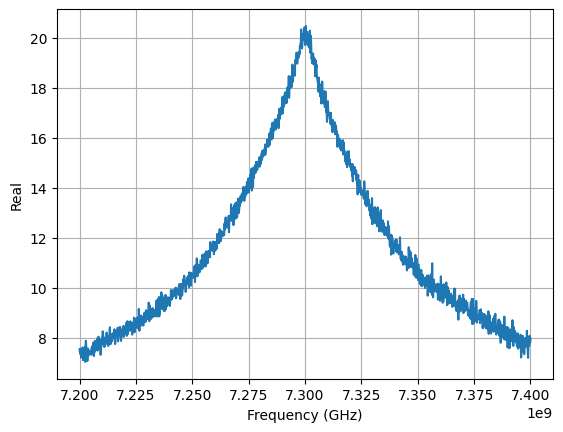

In [37]:
import time

n_points = 1501
f_center =7.3* GHz
f_span = 200e-3* GHz
x_array = np.linspace(f_center - f_span/2, f_center + f_span/2, n_points)
data = [x_array, y_data]
# for i in range(1):
#     save_data(data, f"ParampGain{i}.txt")
#     # time.sleep(10*60)
plt.plot(x_array, y_data)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Real")
plt.grid()
plt.show()


# plt.plot(x_array, real)
# plt.plot(x_array, imag)

# plt.grid()

In [38]:
data = [x_array, y_data]
save_data(data, "Paramp_response.txt")
# path = r"D:\RF Components Characterization\SS cables\\"
# save_data(data, "1gg.txt", path = path )

In [505]:
data1=np.transpose(np.genfromtxt( r"D:\RF Components Characterization\HEMTs\Output26\RoundTripGain_RT_-30dBm.txt"))
data2=np.transpose(np.genfromtxt( r"D:\RF Components Characterization\HEMTs\Output31-NewHEMT-2177H\RoundTripGain_RT_-30dBm.txt"))
data3=np.transpose(np.genfromtxt( r"D:\RF Components Characterization\HEMTs\Output30-RepairedHEMT-2212H\RoundTripGain_RT_-30dBm.txt"))
data4=np.transpose(np.genfromtxt( r"D:\RF Components Characterization\HEMTs\Output27\RoundTripGain_RT_-30dBm.txt"))

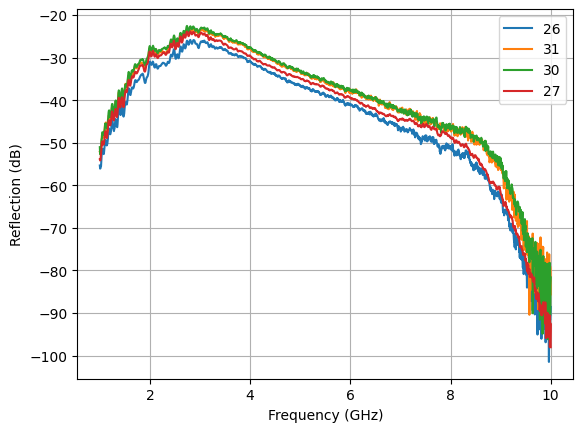

In [508]:
plt.plot(1e-9*data1[0], data1[1], label="26")
plt.plot(1e-9*data2[0], data2[1], label="31")
plt.plot(1e-9*data3[0], data3[1], label="30")
plt.plot(1e-9*data4[0], data4[1], label="27")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Reflection (dB)")
plt.legend()
plt.grid()